In [1]:
import os
import shutil
import requests
import zipfile
from time import strftime
from concurrent.futures import ThreadPoolExecutor, as_completed
import random
import math
import gc

import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Input, Layer, Conv2D, MaxPooling2D, Flatten, Dense, InputLayer, BatchNormalization, Dropout, ReLU
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom, RandomBrightness,
    RandomContrast, RandomTranslation, GaussianNoise, Reshape, Resizing, Rescaling
)
from tensorflow.keras.regularizers import L2
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, FalseNegatives, FalsePositives, TruePositives, TrueNegatives, Precision, Recall, AUC
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras.models import load_model
from tensorflow.random import normal
from tensorflow.keras import backend as K


import matplotlib.pyplot as plt
import heapq

2025-04-23 19:19:36.253752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745435976.454275      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745435976.510375      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# BASE_PATH = os.path.dirname(__file__)
BASE_PATH = os.getcwd()

config = {
    "data_folder": os.path.join(BASE_PATH, "data"),
    "POS_PATH": os.path.join(BASE_PATH, 'data' , 'positive'),
    "NEG_PATH": os.path.join(BASE_PATH, 'data', 'negative'),
    "ANC_PATH": os.path.join(BASE_PATH, 'data', 'anchor'),
    "VAL_PATH": os.path.join(BASE_PATH, 'data', 'validation'),

    "dataset_url": "https://www.kaggle.com/api/v1/datasets/download/jessicali9530/lfw-dataset",
    "dataset_url2": "https://www.kaggle.com/api/v1/datasets/download/hearfool/vggface2",
    "save_model_folder": os.path.join(BASE_PATH, "saved_models"),

    "IM_SIZE": 100,
    "REGULARIZATION_RATE": 0.01,
    "DROPOUT_RATE_CONV": 0.3,
    "DROPOUT_RATE_DENSE": 0.5,
    "LEARNING_RATE": 0.0001,
    "EPOCHS": 150,
    "BATCH_SIZE": 256,
    "TRAINING_RATIO": 0.8,
    "VALIDATION_RATIO": 0.1,
    "TESTING_RATIO": 0.1,
    "GENERATOR_ITER": 1,
    "DigiFace_gen_no": 1
}


os.makedirs(config["save_model_folder"], exist_ok=True)
os.makedirs(config["data_folder"], exist_ok=True)
os.makedirs(config["POS_PATH"], exist_ok=True)
os.makedirs(config["NEG_PATH"], exist_ok=True)
os.makedirs(config["ANC_PATH"], exist_ok=True)
os.makedirs(config["VAL_PATH"], exist_ok=True)

In [3]:
# !mkdir -p ~/.kaggle
# !cp /kaggle/input/apiiii/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [4]:
# from kaggle_secrets import UserSecretsClient
# import os
# from kaggle.api.kaggle_api_extended import KaggleApi

# # Get secrets from Kaggle's secret manager
# user_secrets = UserSecretsClient()
# os.environ['KAGGLE_USERNAME'] = user_secrets.get_secret("username")
# os.environ['KAGGLE_KEY'] = user_secrets.get_secret("key")

# # Authenticate with the Kaggle API
# api = KaggleApi()
# api.authenticate()


In [5]:
# !kaggle kernels output agentveer/preprocessing -p /kaggle/working --quiet


In [6]:
!ls ../input/preprocessing

custom.css  __notebook__.ipynb	__pycache__
data.zip    __output__.json	__results__.html


In [7]:
# !mv /kaggle/input/preprocessing/data.zip /kaggle/working/data.zip

In [8]:
!unzip -qd /kaggle/working/ /kaggle/input/preprocessing/data.zip

In [9]:
# !rm ./data.zip

In [10]:
def preprocess(file_path):
    IM_SIZE = config["IM_SIZE"]

    # Read image file
    byte_img = tf.io.read_file(file_path)

    # Automatically decode image (supports PNG, JPEG, BMP, GIF, etc.)
    img = tf.image.decode_image(byte_img, channels=0, expand_animations=False)

    # If it has 4 channels (RGBA), convert to RGB
    img = tf.cond(
        tf.shape(img)[-1] == 4,
        lambda: img[:, :, :3],
        lambda: img
    )

    # Ensure image has shape (height, width, 3)
    img.set_shape([None, None, 3])

    # # Augmentation Layer
    # ########### TODO #############

    # Resize image
    img = tf.image.resize(img, (IM_SIZE, IM_SIZE))

    # Normalize pixel values
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]

    return img

def preprocess_twin(input_img, validation_img, label):
    label = tf.cast(label, tf.float32)
    return ((preprocess(input_img), preprocess(validation_img)), label)

In [11]:
def load_data(raw_data):
    BATCH_SIZE = config["BATCH_SIZE"]
    TRAINING_RATIO = config["TRAINING_RATIO"]
    VALIDATION_RATIO = config["VALIDATION_RATIO"]
    TESTING_RATIO = config["TESTING_RATIO"]

    DATA_SIZE = raw_data.cardinality().numpy()

    TRAINING_SIZE = round(DATA_SIZE*TRAINING_RATIO)
    VALIDATION_SIZE = round(DATA_SIZE*VALIDATION_RATIO)
    TESTING_SIZE = round(DATA_SIZE*TESTING_RATIO)

    data = raw_data.map(preprocess_twin)

    data = data.shuffle(buffer_size=2048)
    # Training partition
    train_data = data.take(TRAINING_SIZE + VALIDATION_SIZE)
    train_data = train_data.batch(BATCH_SIZE)

    # Validation partition
    # validation_data = data.skip(TRAINING_SIZE)
    # validation_data = validation_data.take(VALIDATION_SIZE)
    # validation_data = validation_data.batch(BATCH_SIZE)
    validation_data = None

    # Testing partition
    test_data = data.skip(TRAINING_SIZE + VALIDATION_SIZE)
    test_data = test_data.take(TESTING_SIZE)
    test_data = test_data.batch(BATCH_SIZE)

    return train_data, validation_data, test_data

In [12]:
def load_data_generator():
    n = 1

    POS_PATH = config["POS_PATH"]
    NEG_PATH = config["NEG_PATH"]
    ANC_PATH = config["ANC_PATH"]

    POS_PATH_child_dir = None
    ANC_PATH_child_dir = None

    try:
        POS_PATH_child_dir = os.listdir(POS_PATH)
        ANC_PATH_child_dir = os.listdir(ANC_PATH)
        for p in POS_PATH_child_dir:
            if p.startswith("."):
                POS_PATH_child_dir.remove(p)
        for p in ANC_PATH_child_dir:
            if p.startswith("."):
                ANC_PATH_child_dir.remove(p)
    except OSError as e:
        print(f"An error occurred: {e}")

    # negative raw data
    NEG_PATH_P = os.path.join(NEG_PATH, "")
    negative = tf.data.Dataset.list_files(NEG_PATH_P + '*.jpg')
    # negative_size = negative.cardinality().numpy()

    archor_positive = []

    for p in POS_PATH_child_dir:
        POS_PATH_P = os.path.join(POS_PATH, p, "")
        ANC_PATH_P = os.path.join(ANC_PATH, p, "")

        anchor = tf.data.Dataset.list_files(ANC_PATH_P + '*.jpg')
        positive = tf.data.Dataset.list_files(POS_PATH_P + '*.jpg')

        archor_positive.append((anchor, positive))

    POS_PATH_child_dir = None
    ANC_PATH_child_dir = None

    Data = None
    
    for anchor, positive in archor_positive:
        anchor = anchor.shuffle(buffer_size=1000)
        positive = positive.shuffle(buffer_size=1000)
        # negative = tf.data.Dataset.list_files(NEG_PATH_P + '*.jpg')

        anchor_size = anchor.cardinality().numpy()
        positive_size = positive.cardinality().numpy()

        shuffled_negative = negative.shuffle(buffer_size=10000).take(anchor_size)

        positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(anchor_size))))
        shuffled_negative = tf.data.Dataset.zip((anchor, shuffled_negative, tf.data.Dataset.from_tensor_slices(tf.zeros(anchor_size))))

        if Data is None:
            Data = positives.concatenate(shuffled_negative)
        else:
            Data = Data.concatenate(positives.concatenate(shuffled_negative))

    yield load_data(Data)

In [13]:
IM_SIZE = config["IM_SIZE"]
REGULARIZATION_RATE = config["REGULARIZATION_RATE"]
DROPOUT_RATE_CONV = config["DROPOUT_RATE_CONV"]
DROPOUT_RATE_DENSE = config["DROPOUT_RATE_DENSE"]

class EmbeddingModel(Model):
    def __init__(self, **kwargs):
        super(EmbeddingModel, self).__init__(name='embedding', **kwargs)

        self.conv1 = Conv2D(
            filters=64,
            kernel_size=(10, 10),
            activation=None,
            kernel_initializer=RandomNormal(mean=0.0, stddev=1e-2),
            bias_initializer=RandomNormal(mean=0.5, stddev=1e-2),
            kernel_regularizer=L2(REGULARIZATION_RATE)
        )
        self.bn1 = BatchNormalization()
        self.act1 = ReLU()
        self.pool1 = MaxPooling2D((2, 2), strides=2, padding='same')
        self.drop1 = Dropout(DROPOUT_RATE_CONV)

        self.conv2 = Conv2D(
            filters=128,
            kernel_size=(7, 7),
            activation=None,
            kernel_initializer=RandomNormal(mean=0.0, stddev=1e-2),
            bias_initializer=RandomNormal(mean=0.5, stddev=1e-2),
            kernel_regularizer=L2(REGULARIZATION_RATE)
        )
        self.bn2 = BatchNormalization()
        self.act2 = ReLU()
        self.pool2 = MaxPooling2D((2, 2), strides=2, padding='same')
        self.drop2 = Dropout(DROPOUT_RATE_CONV)

        self.conv3 = Conv2D(
            filters=128,
            kernel_size=(4, 4),
            activation=None,
            kernel_initializer=RandomNormal(mean=0.0, stddev=1e-2),
            bias_initializer=RandomNormal(mean=0.5, stddev=1e-2),
            kernel_regularizer=L2(REGULARIZATION_RATE)
        )
        self.bn3 = BatchNormalization()
        self.act3 = ReLU()
        self.pool3 = MaxPooling2D((2, 2), strides=2, padding='same')
        self.drop3 = Dropout(DROPOUT_RATE_CONV)

        self.conv4 = Conv2D(
            filters=256,
            kernel_size=(4, 4),
            activation=None,
            kernel_initializer=RandomNormal(mean=0.0, stddev=1e-2),
            bias_initializer=RandomNormal(mean=0.5, stddev=1e-2),
            kernel_regularizer=L2(REGULARIZATION_RATE)
        )
        self.bn4 = BatchNormalization()
        self.act4 = ReLU()
        self.flatten = Flatten()
        self.drop4 = Dropout(DROPOUT_RATE_CONV)

        self.dense = Dense(
            4096,
            activation=None,
            kernel_initializer=RandomNormal(mean=0.0, stddev=2e-1),
            bias_initializer=RandomNormal(mean=0.5, stddev=1e-2),
            kernel_regularizer=L2(REGULARIZATION_RATE)
        )
        self.bn_dense = BatchNormalization()
        self.act_dense = ReLU()
        self.drop5 = Dropout(DROPOUT_RATE_DENSE)

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.pool2(x)
        x = self.drop2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.pool3(x)
        x = self.drop3(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.act4(x)
        x = self.flatten(x)
        x = self.drop4(x)

        x = self.dense(x)
        x = self.bn_dense(x)
        x = self.act_dense(x)
        x = self.drop5(x)

        return x

# Siamese L1 Distance class
class L1Dist(Layer):
    def __init__(self):
        super(L1Dist, self).__init__(name='distance')

    def call(self, anchor_embedding, validation_embedding):
        return tf.math.abs(anchor_embedding - validation_embedding)

@register_keras_serializable()
class SiameseModel(Model):
    def __init__(self, **kwargs):
        super(SiameseModel, self).__init__(**kwargs)

        self.embedding = EmbeddingModel()

        self.l1_distance = L1Dist()

        self.classifier = Dense(
            1,
            activation='sigmoid',
            kernel_initializer=RandomNormal(mean=0.0, stddev=2e-1),
            bias_initializer=RandomNormal(mean=0.5, stddev=1e-2),
            kernel_regularizer=L2(REGULARIZATION_RATE)
        )

    def call(self, inputs):
        input_image, validation_image = inputs[0], inputs[1]


        # Get embeddings
        input_embedding = self.embedding(input_image)
        validation_embedding = self.embedding(validation_image)

        # Calculate distance
        distance = self.l1_distance(input_embedding, validation_embedding)

        # Classification
        output = self.classifier(distance)

        return output

    def get_embedding_vector(self, img_name_list):
        output = []

        embedding = None

        for name, img in img_name_list:
            img = tf.expand_dims(img, axis=0)
            embedding_vec = self.embedding.predict(img)

            output.append((name, embedding_vec))

        return output

    def custom_prediction(self, input_img, val_img_embedding, verbose=False):
        """
        val_img_embedding = [
            ("Ankit kumar", [[33, 4, 4, 534 ...]]),
            ("Anup kumar", [[33, 4, 4, 534 ...]]),
            ("Ankit kumar", [[33, 4, 4, 534 ...]]),
        ]
        """

        input_img = tf.expand_dims(input_img, axis=0)  # reshape (100, 100, 3) -> (1, 100, 100, 3)
        person = self.embedding.predict(input_img)

        if verbose:
            print("Person Embedding vector: ", person)

        pq = []

        for name, val_emb in val_img_embedding:
            dist = self.l1_distance(person, val_emb)
            output = self.classifier(dist)

            if verbose:
                print("L1 dist vector: ", dist)
                print("Classifier Output: ", output)

            output =  output.numpy().item()

            if len(pq) < 3:
                heapq.heappush(pq, (output, name))
            else:
                p, n = heapq.heappop(pq)
                if output > p:
                    heapq.heappush(pq, (output, name))
                else:
                    heapq.heappush(pq, (p, n))

        value = []
        while pq:
            value.append(heapq.heappop(pq))

        value.reverse()

        return value

custom_objects = {'SiameseModel': SiameseModel, 'EmbeddingModel': EmbeddingModel, 'L1Dist': L1Dist}

In [14]:
model = SiameseModel()
dummy_input = tf.random.normal((1, config["IM_SIZE"], config["IM_SIZE"], 3))
model((dummy_input, dummy_input))  # triggers model build
model.summary()

I0000 00:00:1745436050.048118      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1745436052.373724      19 cuda_dnn.cc:529] Loaded cuDNN version 90300


Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (EmbeddingModel)           │ ?                           │      38,979,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ distance (L1Dist)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 1)                      │           4,097 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,983,233 (148.71 MB)

 Trainable params: 38,973,889 (148.67 MB)

 Non-trainable params: 9,344 (36.50 KB)

In [15]:
def training(generator, saved_model_path=None):
    model = None

    def scheduler(epoch, lr):
      return lr * 0.99  # reduce after 1 epochs

    lr_callback = LearningRateScheduler(scheduler)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

    checkpoint_callback = ModelCheckpoint(
        'best_weights.keras',
        monitor = 'precision',
        mode='max',
        verbose=1,
        save_best_only = True
    )

    if saved_model_path:
        print("Loading saved model")

        # Load the model with custom_objects
        model = load_model(saved_model_path, custom_objects=custom_objects)
    else:
        model = SiameseModel()
        dummy_input = normal((1, config["IM_SIZE"], config["IM_SIZE"], 3))
        model((dummy_input, dummy_input))  # triggers model build

        loss_function = BinaryCrossentropy()
        metrics = [TruePositives(name='tp'), FalsePositives(name='fp'), TrueNegatives(name='tn'),
                   FalseNegatives(name='fn'), BinaryAccuracy(name='accuracy'),
                   Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]


        model.compile(
            optimizer = Adam(learning_rate = config["LEARNING_RATE"]),
            loss = loss_function,
            metrics = metrics,
        )

    model.summary()

    data_gen = generator()
    combined_history = {}

    for train_data, validation_data, test_data in data_gen:

        history = model.fit(
            train_data,
            epochs = config["EPOCHS"],
            verbose = 1,
            callbacks = [lr_callback, lr_scheduler, checkpoint_callback]
        )

        for key, values in history.history.items():
            if key not in combined_history:
                combined_history[key] = []
            combined_history[key].extend(values)

        evaluation_metrics = model.evaluate(test_data)
        print("Test Evaluation:", dict(zip(model.metrics_names, evaluation_metrics)))

        del train_data, validation_data, test_data

    os.makedirs(config["save_model_folder"], exist_ok=True)
    if saved_model_path:
        model.save(saved_model_path)
    else:
        path = os.path.join(config["save_model_folder"], f'model-{strftime("%Y%m%d-%H%M%S")}.keras')
        model.save(path)

    return combined_history

In [16]:
history = training(load_data_generator)

Model: "siamese_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (EmbeddingModel)           │ ?                           │      38,979,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ distance (L1Dist)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (1, 1)                      │           4,097 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,983,233 (148.71 MB)

 Trainable params: 38,973,889 (148.67 MB)

 Non-trainable params: 9,344 (36.50 KB)

Epoch 1/150


I0000 00:00:1745436082.125236      61 service.cc:148] XLA service 0x7d0524002250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745436082.126236      61 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2025-04-23 19:21:30.897690: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[64,3,10,10]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,3,100,100]{3,2,1,0}, f32[256,64,91,91]{3,2,1,0}), window={size=10x10}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-04-23 19:21:31.513582: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.616049133s
Trying alg

696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5902 - auc: 0.6273 - fn: 14251.7500 - fp: 20830.2832 - loss: 13275.4893 - precision: 0.5782 - recall: 0.6879 - tn: 23779.7754 - tp: 30353.8281
Epoch 1: precision improved from -inf to 0.61321, saving model to best_weights.keras


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,auc,fn,fp,loss,precision,recall,tn,tp,learning_rate.
  callback.on_epoch_end(epoch, logs)


696/696 ━━━━━━━━━━━━━━━━━━━━ 246s 311ms/step - accuracy: 0.5902 - auc: 0.6274 - fn: 14271.3877 - fp: 20855.5586 - loss: 13273.1826 - precision: 0.5782 - recall: 0.6879 - tn: 23818.2266 - tp: 30397.7324 - learning_rate: 9.9000e-05
Epoch 2/150
695/696 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.6712 - auc: 0.7328 - fn: 13006.0312 - fp: 16042.9141 - loss: 7767.5752 - precision: 0.6604 - recall: 0.7074 - tn: 28502.5703 - tp: 31536.4844
Epoch 2: precision improved from 0.61321 to 0.66824, saving model to best_weights.keras
696/696 ━━━━━━━━━━━━━━━━━━━━ 222s 314ms/step - accuracy: 0.6712 - auc: 0.7328 - fn: 13042.4336 - fp: 16086.9082 - loss: 7764.9062 - precision: 0.6605 - recall: 0.7074 - tn: 28586.2324 - tp: 31627.3320 - learning_rate: 9.8010e-05
Epoch 3/150
695/696 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7054 - auc: 0.7753 - fn: 11625.5693 - fp: 14352.7959 - loss: 4550.8130 - precision: 0.6925 - recall: 0.7419 - tn: 30193.2969 - tp: 32916.3398
Epoch 3: precision improved fro

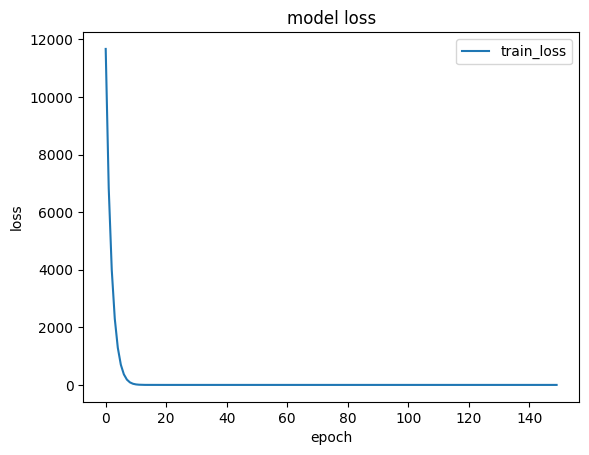

In [17]:
plt.plot(history['loss'])
# plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

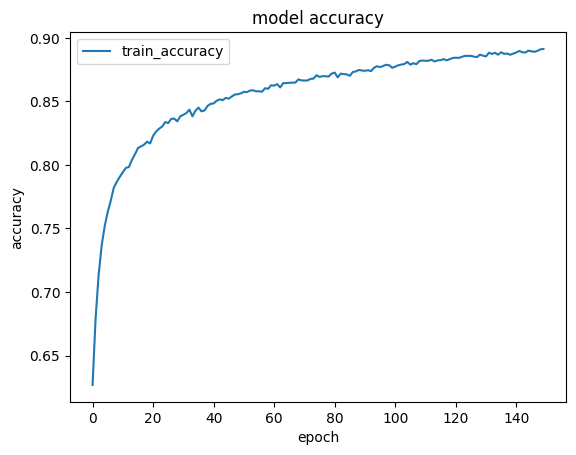

In [18]:
plt.plot(history['accuracy'])
# plt.plot(history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

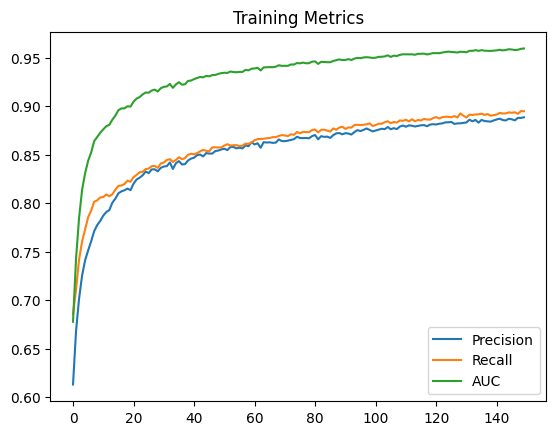

In [19]:
plt.plot(history['precision'], label='Precision')
plt.plot(history['recall'], label='Recall')
plt.plot(history['auc'], label='AUC')
plt.legend()
plt.title("Training Metrics")
plt.show()

In [20]:
!rm -rfd ./data